# OpenMeteo Data Consistency Analysis

Investigation of data consistency issues between OpenMeteo files downloaded at different times.

**Problem**: November 2023 file (503MB) is 5x larger than November 2024 file (97MB) despite using the same downloader.

**Version**: V3

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

## 1. Data Loading and Overview

In [2]:
file_2023 = '/Users/vojtech/Code/Bard89/Project-Data/data/openmeteo/processed/jp_openmeteo_weather_20231101_to_20231130.csv'
file_2024 = '/Users/vojtech/Code/Bard89/Project-Data/data/openmeteo/processed/jp_openmeteo_weather_20241101_to_20241130.csv'

print("Loading data files...")
print("="*60)

file_size_2023 = os.path.getsize(file_2023) / (1024**2)
file_size_2024 = os.path.getsize(file_2024) / (1024**2)

print(f"November 2023 file: {file_size_2023:.1f} MB")
print(f"November 2024 file: {file_size_2024:.1f} MB")
print(f"Size ratio: {file_size_2023/file_size_2024:.1f}x")

df_2023 = pd.read_csv(file_2023)
df_2024 = pd.read_csv(file_2024)

print(f"\n2023 Dataset shape: {df_2023.shape[0]:,} rows × {df_2023.shape[1]} columns")
print(f"2024 Dataset shape: {df_2024.shape[0]:,} rows × {df_2024.shape[1]} columns")
print(f"Row ratio: {df_2023.shape[0]/df_2024.shape[0]:.1f}x")

Loading data files...
November 2023 file: 503.1 MB
November 2024 file: 96.7 MB
Size ratio: 5.2x

2023 Dataset shape: 3,295,440 rows × 14 columns
2024 Dataset shape: 645,120 rows × 14 columns
Row ratio: 5.1x


In [3]:
print("Dataset Structure Comparison:")
print("="*60)
print("\n2023 Columns:", list(df_2023.columns))
print("\n2024 Columns:", list(df_2024.columns))
print("\nColumns match:", list(df_2023.columns) == list(df_2024.columns))

print("\n2023 First 5 rows:")
display(df_2023.head())

print("\n2024 First 5 rows:")
display(df_2024.head())

Dataset Structure Comparison:

2023 Columns: ['timestamp', 'value', 'sensor_id', 'location_id', 'location_name', 'latitude', 'longitude', 'parameter', 'unit', 'city', 'country', 'data_source', 'level', 'quality_flag']

2024 Columns: ['timestamp', 'value', 'sensor_id', 'location_id', 'location_name', 'latitude', 'longitude', 'parameter', 'unit', 'city', 'country', 'data_source', 'level', 'quality_flag']

Columns match: True

2023 First 5 rows:


,timestamp,value,sensor_id,location_id,location_name,latitude,longitude,parameter,unit,city,country,data_source,level,quality_flag
0,2023-11-01T00:00:00,0.00,OPENMETEO_JP_001_direct_radiation,OPENMETEO_JP_001,Osaka,34.69,135.50,solar_radiation,W/m²,Osaka,JP,openmeteo,surface,good
1,2023-11-01T01:00:00,0.00,OPENMETEO_JP_001_direct_radiation,OPENMETEO_JP_001,Osaka,34.69,135.50,solar_radiation,W/m²,Osaka,JP,openmeteo,surface,good
2,2023-11-01T02:00:00,0.00,OPENMETEO_JP_001_direct_radiation,OPENMETEO_JP_001,Osaka,34.69,135.50,solar_radiation,W/m²,Osaka,JP,openmeteo,surface,good
3,2023-11-01T03:00:00,0.00,OPENMETEO_JP_001_direct_radiation,OPENMETEO_JP_001,Osaka,34.69,135.50,solar_radiation,W/m²,Osaka,JP,openmeteo,surface,good
4,2023-11-01T04:00:00,0.00,OPENMETEO_JP_001_direct_radiation,OPENMETEO_JP_001,Osaka,34.69,135.50,solar_radiation,W/m²,Osaka,JP,openmeteo,surface,good



2024 First 5 rows:


,timestamp,value,sensor_id,location_id,location_name,latitude,longitude,parameter,unit,city,country,data_source,level,quality_flag
0,2024-11-01T00:00:00,11.10,OPENMETEO_JP_000_temperature_2m,OPENMETEO_JP_000,Tokyo,35.68,139.65,temperature,c,Tokyo,JP,openmeteo,surface,good
1,2024-11-01T01:00:00,11.20,OPENMETEO_JP_000_temperature_2m,OPENMETEO_JP_000,Tokyo,35.68,139.65,temperature,c,Tokyo,JP,openmeteo,surface,good
2,2024-11-01T02:00:00,11.10,OPENMETEO_JP_000_temperature_2m,OPENMETEO_JP_000,Tokyo,35.68,139.65,temperature,c,Tokyo,JP,openmeteo,surface,good
3,2024-11-01T03:00:00,10.70,OPENMETEO_JP_000_temperature_2m,OPENMETEO_JP_000,Tokyo,35.68,139.65,temperature,c,Tokyo,JP,openmeteo,surface,good
4,2024-11-01T04:00:00,10.70,OPENMETEO_JP_000_temperature_2m,OPENMETEO_JP_000,Tokyo,35.68,139.65,temperature,c,Tokyo,JP,openmeteo,surface,good


## 2. Location and Parameter Analysis

In [4]:
locations_2023 = df_2023['location_id'].unique()
locations_2024 = df_2024['location_id'].unique()

parameters_2023 = df_2023['parameter'].unique()
parameters_2024 = df_2024['parameter'].unique()

print("Location Analysis:")
print("="*60)
print(f"2023 unique locations: {len(locations_2023)}")
print(f"2024 unique locations: {len(locations_2024)}")
print(f"Location ratio: {len(locations_2023)/len(locations_2024):.1f}x")

common_locations = set(locations_2024).intersection(set(locations_2023))
print(f"\nCommon locations: {len(common_locations)}")
print(f"Locations only in 2023: {len(set(locations_2023) - set(locations_2024))}")
print(f"Locations only in 2024: {len(set(locations_2024) - set(locations_2023))}")

print("\n" + "="*60)
print("Parameter Analysis:")
print("="*60)
print(f"2023 parameters: {sorted(parameters_2023)}")
print(f"2024 parameters: {sorted(parameters_2024)}")
print(f"Parameters match: {set(parameters_2023) == set(parameters_2024)}")

Location Analysis:
2023 unique locations: 510
2024 unique locations: 100
Location ratio: 5.1x

Common locations: 99
Locations only in 2023: 411
Locations only in 2024: 1

Parameter Analysis:
2023 parameters: ['cloud_cover', 'dew_point', 'humidity', 'precipitation', 'pressure', 'solar_radiation', 'temperature', 'winddirection', 'windspeed']
2024 parameters: ['cloud_cover', 'dew_point', 'humidity', 'precipitation', 'pressure', 'solar_radiation', 'temperature', 'winddirection', 'windspeed']
Parameters match: True


In [5]:
param_counts_2023 = df_2023['parameter'].value_counts()
param_counts_2024 = df_2024['parameter'].value_counts()

comparison_df = pd.DataFrame({
    '2023_count': param_counts_2023,
    '2024_count': param_counts_2024
}).fillna(0)
comparison_df['ratio'] = comparison_df['2023_count'] / comparison_df['2024_count']

print("Records per Parameter:")
print("="*60)
display(comparison_df)

Records per Parameter:


,2023_count,2024_count,ratio
parameter,,,
cloud_cover,366480,72000,5.09
dew_point,366480,72000,5.09
humidity,366480,72000,5.09
precipitation,365760,72000,5.08
pressure,365760,71280,5.13
solar_radiation,366480,72000,5.09
temperature,366480,71280,5.14
winddirection,365760,70560,5.18
windspeed,365760,72000,5.08


## 3. Spatial Coverage Analysis

In [6]:
df_2023['timestamp'] = pd.to_datetime(df_2023['timestamp'])
df_2024['timestamp'] = pd.to_datetime(df_2024['timestamp'])

locs_2023 = df_2023[['location_id', 'latitude', 'longitude']].drop_duplicates()
locs_2024 = df_2024[['location_id', 'latitude', 'longitude']].drop_duplicates()

print("Geographic Coverage:")
print("="*60)
print(f"2023 - Latitude range: {locs_2023['latitude'].min():.2f} to {locs_2023['latitude'].max():.2f}")
print(f"2023 - Longitude range: {locs_2023['longitude'].min():.2f} to {locs_2023['longitude'].max():.2f}")
print(f"\n2024 - Latitude range: {locs_2024['latitude'].min():.2f} to {locs_2024['latitude'].max():.2f}")
print(f"2024 - Longitude range: {locs_2024['longitude'].min():.2f} to {locs_2024['longitude'].max():.2f}")

unique_lats_2023 = sorted(locs_2023['latitude'].unique())
unique_lats_2024 = sorted(locs_2024['latitude'].unique())
unique_lons_2023 = sorted(locs_2023['longitude'].unique())
unique_lons_2024 = sorted(locs_2024['longitude'].unique())

print(f"\n2023 - Unique latitudes: {len(unique_lats_2023)}, Unique longitudes: {len(unique_lons_2023)}")
print(f"2024 - Unique latitudes: {len(unique_lats_2024)}, Unique longitudes: {len(unique_lons_2024)}")

if len(unique_lats_2023) > 1:
    lat_spacing_2023 = np.diff(unique_lats_2023).mean()
    print(f"\n2023 - Average latitude spacing: {lat_spacing_2023:.3f}°")
if len(unique_lats_2024) > 1:
    lat_spacing_2024 = np.diff(unique_lats_2024).mean()
    print(f"2024 - Average latitude spacing: {lat_spacing_2024:.3f}°")

if len(unique_lons_2023) > 1:
    lon_spacing_2023 = np.diff(unique_lons_2023).mean()
    print(f"2023 - Average longitude spacing: {lon_spacing_2023:.3f}°")
if len(unique_lons_2024) > 1:
    lon_spacing_2024 = np.diff(unique_lons_2024).mean()
    print(f"2024 - Average longitude spacing: {lon_spacing_2024:.3f}°")

Geographic Coverage:
2023 - Latitude range: 24.00 to 44.00
2023 - Longitude range: 123.00 to 145.00

2024 - Latitude range: 24.00 to 43.06
2024 - Longitude range: 123.00 to 145.00

2023 - Unique latitudes: 50, Unique longitudes: 52
2024 - Unique latitudes: 34, Unique longitudes: 53

2023 - Average latitude spacing: 0.408°
2024 - Average latitude spacing: 0.578°
2023 - Average longitude spacing: 0.431°
2024 - Average longitude spacing: 0.423°


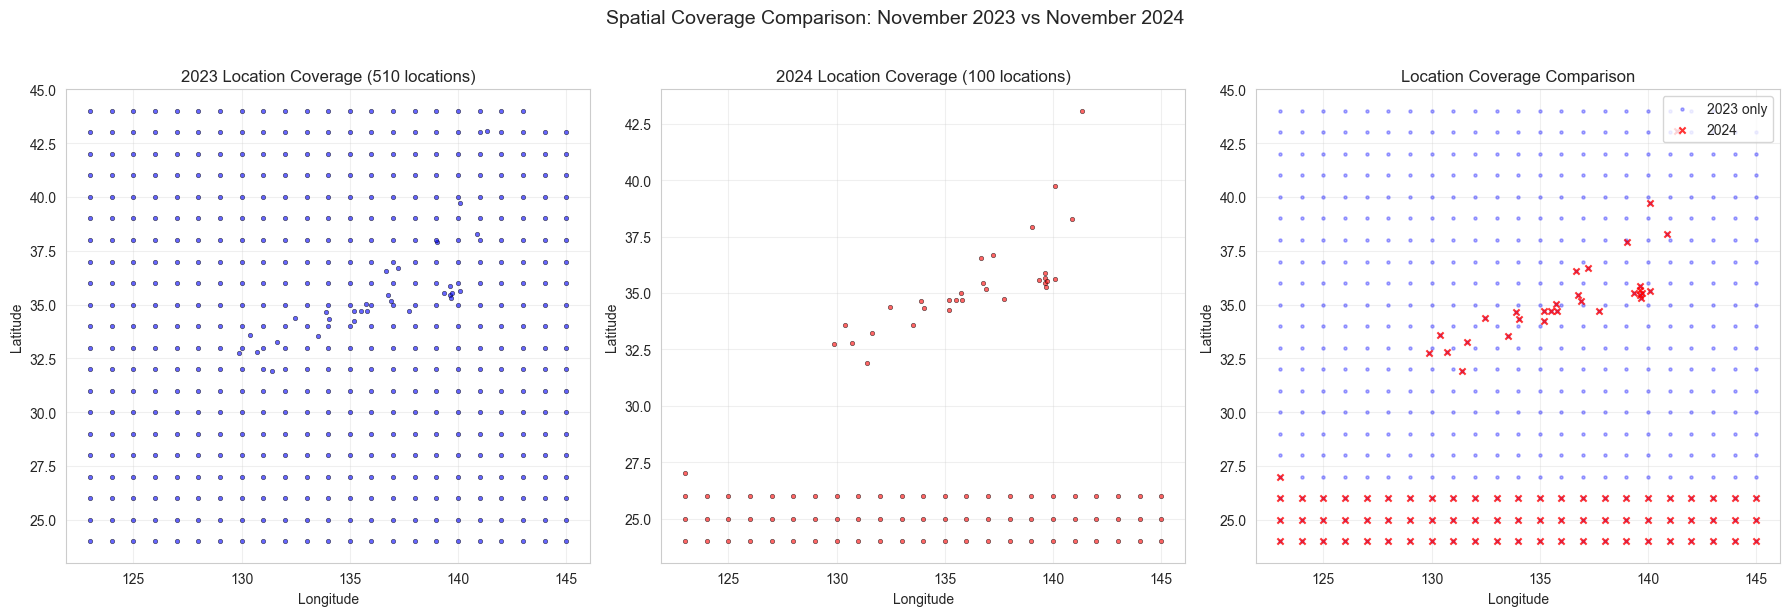

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].scatter(locs_2023['longitude'], locs_2023['latitude'], 
               s=10, alpha=0.6, c='blue', edgecolors='black', linewidth=0.5)
axes[0].set_title(f'2023 Location Coverage ({len(locs_2023)} locations)', fontsize=12)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(locs_2024['longitude'], locs_2024['latitude'], 
               s=10, alpha=0.6, c='red', edgecolors='black', linewidth=0.5)
axes[1].set_title(f'2024 Location Coverage ({len(locs_2024)} locations)', fontsize=12)
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].grid(True, alpha=0.3)

axes[2].scatter(locs_2023['longitude'], locs_2023['latitude'], 
               s=5, alpha=0.3, c='blue', label='2023 only')
axes[2].scatter(locs_2024['longitude'], locs_2024['latitude'], 
               s=20, alpha=0.8, c='red', label='2024', marker='x')
axes[2].set_title('Location Coverage Comparison', fontsize=12)
axes[2].set_xlabel('Longitude')
axes[2].set_ylabel('Latitude')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Spatial Coverage Comparison: November 2023 vs November 2024', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Temporal Consistency Analysis

In [8]:
print("Temporal Coverage:")
print("="*60)

print(f"2023 - Date range: {df_2023['timestamp'].min()} to {df_2023['timestamp'].max()}")
print(f"2024 - Date range: {df_2024['timestamp'].min()} to {df_2024['timestamp'].max()}")

unique_timestamps_2023 = sorted(df_2023['timestamp'].unique())
unique_timestamps_2024 = sorted(df_2024['timestamp'].unique())

print(f"\n2023 - Unique timestamps: {len(unique_timestamps_2023)}")
print(f"2024 - Unique timestamps: {len(unique_timestamps_2024)}")

expected_hours = 30 * 24
print(f"\nExpected hours in November: {expected_hours}")
print(f"2023 coverage: {len(unique_timestamps_2023)/expected_hours*100:.1f}%")
print(f"2024 coverage: {len(unique_timestamps_2024)/expected_hours*100:.1f}%")

sample_location = list(common_locations)[0] if common_locations else locations_2024[0]
sample_param = 'temperature'

sample_2023 = df_2023[(df_2023['location_id'] == sample_location) & 
                       (df_2023['parameter'] == sample_param)].sort_values('timestamp')
sample_2024 = df_2024[(df_2024['location_id'] == sample_location) & 
                       (df_2024['parameter'] == sample_param)].sort_values('timestamp')

print(f"\nSample location '{sample_location}' - {sample_param}:")
print(f"2023 records: {len(sample_2023)}")
print(f"2024 records: {len(sample_2024)}")

Temporal Coverage:
2023 - Date range: 2023-11-01 00:00:00 to 2023-11-30 23:00:00
2024 - Date range: 2024-11-01 00:00:00 to 2024-11-30 23:00:00

2023 - Unique timestamps: 720
2024 - Unique timestamps: 720

Expected hours in November: 720
2023 coverage: 100.0%
2024 coverage: 100.0%

Sample location 'OPENMETEO_JP_019' - temperature:
2023 records: 720
2024 records: 720


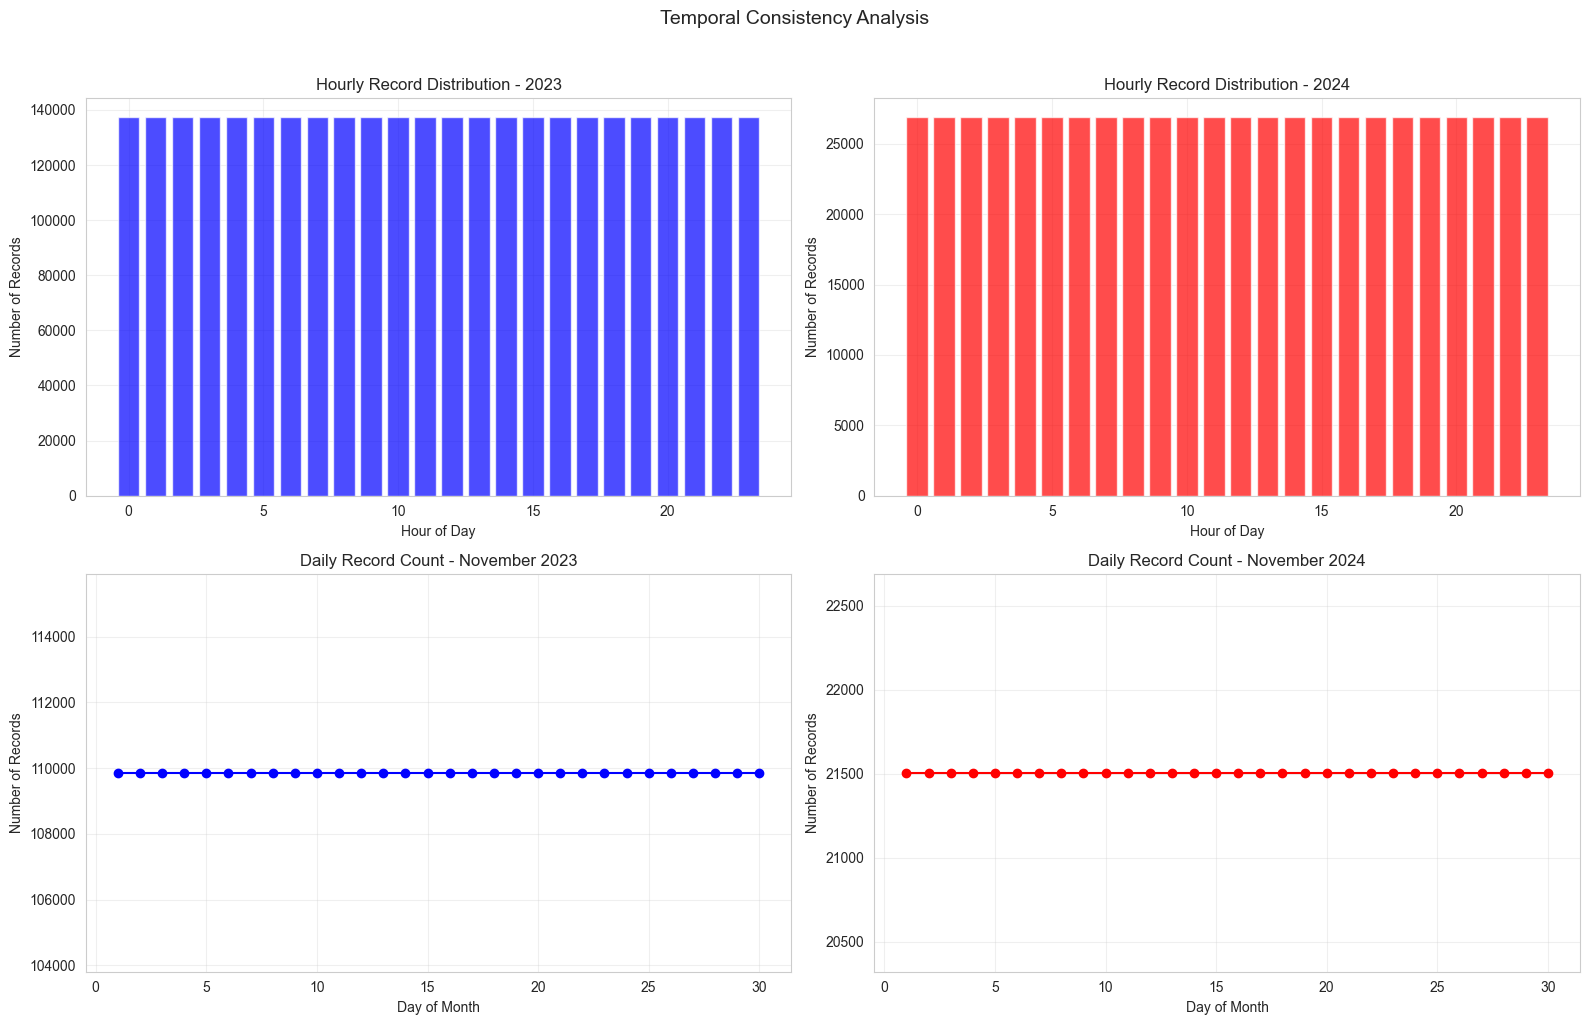

In [9]:
df_2023['hour'] = df_2023['timestamp'].dt.hour
df_2024['hour'] = df_2024['timestamp'].dt.hour
df_2023['day'] = df_2023['timestamp'].dt.day
df_2024['day'] = df_2024['timestamp'].dt.day

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

hourly_2023 = df_2023.groupby('hour').size()
hourly_2024 = df_2024.groupby('hour').size()

axes[0, 0].bar(hourly_2023.index, hourly_2023.values, alpha=0.7, label='2023', color='blue')
axes[0, 0].set_title('Hourly Record Distribution - 2023', fontsize=12)
axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].set_ylabel('Number of Records')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].bar(hourly_2024.index, hourly_2024.values, alpha=0.7, label='2024', color='red')
axes[0, 1].set_title('Hourly Record Distribution - 2024', fontsize=12)
axes[0, 1].set_xlabel('Hour of Day')
axes[0, 1].set_ylabel('Number of Records')
axes[0, 1].grid(True, alpha=0.3)

daily_2023 = df_2023.groupby('day').size()
daily_2024 = df_2024.groupby('day').size()

axes[1, 0].plot(daily_2023.index, daily_2023.values, marker='o', label='2023', color='blue')
axes[1, 0].set_title('Daily Record Count - November 2023', fontsize=12)
axes[1, 0].set_xlabel('Day of Month')
axes[1, 0].set_ylabel('Number of Records')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(daily_2024.index, daily_2024.values, marker='o', label='2024', color='red')
axes[1, 1].set_title('Daily Record Count - November 2024', fontsize=12)
axes[1, 1].set_xlabel('Day of Month')
axes[1, 1].set_ylabel('Number of Records')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Temporal Consistency Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Data Completeness and Missing Values

In [10]:
print("Missing Data Analysis:")
print("="*60)

missing_2023 = df_2023.isnull().sum()
missing_2024 = df_2024.isnull().sum()

missing_comparison = pd.DataFrame({
    '2023_missing': missing_2023,
    '2023_missing_%': (missing_2023 / len(df_2023) * 100).round(2),
    '2024_missing': missing_2024,
    '2024_missing_%': (missing_2024 / len(df_2024) * 100).round(2)
})

display(missing_comparison)

expected_records_per_location = 30 * 24 * 9

location_completeness_2023 = df_2023.groupby('location_id').size() / expected_records_per_location * 100
location_completeness_2024 = df_2024.groupby('location_id').size() / expected_records_per_location * 100

print(f"\nLocation Data Completeness:")
print(f"2023 - Mean completeness: {location_completeness_2023.mean():.1f}%")
print(f"2023 - Median completeness: {location_completeness_2023.median():.1f}%")
print(f"2023 - Min completeness: {location_completeness_2023.min():.1f}%")
print(f"2023 - Max completeness: {location_completeness_2023.max():.1f}%")

print(f"\n2024 - Mean completeness: {location_completeness_2024.mean():.1f}%")
print(f"2024 - Median completeness: {location_completeness_2024.median():.1f}%")
print(f"2024 - Min completeness: {location_completeness_2024.min():.1f}%")
print(f"2024 - Max completeness: {location_completeness_2024.max():.1f}%")

Missing Data Analysis:


,2023_missing,2023_missing_%,2024_missing,2024_missing_%
timestamp,0,0.00,0,0.00
value,0,0.00,0,0.00
sensor_id,0,0.00,0,0.00
location_id,0,0.00,0,0.00
location_name,0,0.00,0,0.00
latitude,0,0.00,0,0.00
longitude,0,0.00,0,0.00
parameter,0,0.00,0,0.00
unit,0,0.00,0,0.00
city,3111840,94.43,451440,69.98



Location Data Completeness:
2023 - Mean completeness: 99.7%
2023 - Median completeness: 100.0%
2023 - Min completeness: 22.2%
2023 - Max completeness: 100.0%

2024 - Mean completeness: 99.6%
2024 - Median completeness: 100.0%
2024 - Min completeness: 88.9%
2024 - Max completeness: 100.0%


## 6. Value Consistency for Common Locations

In [11]:
if len(common_locations) > 0:
    print(f"Analyzing {len(common_locations)} common locations...")
    print("="*60)
    
    sample_locations = list(common_locations)[:5]
    
    for loc in sample_locations:
        print(f"\nLocation: {loc}")
        
        loc_2023 = df_2023[df_2023['location_id'] == loc]
        loc_2024 = df_2024[df_2024['location_id'] == loc]
        
        print(f"  2023 records: {len(loc_2023)}")
        print(f"  2024 records: {len(loc_2024)}")
        
        for param in ['temperature', 'humidity', 'precipitation']:
            if param in parameters_2023 and param in parameters_2024:
                val_2023 = loc_2023[loc_2023['parameter'] == param]['value'].mean()
                val_2024 = loc_2024[loc_2024['parameter'] == param]['value'].mean()
                
                if not pd.isna(val_2023) and not pd.isna(val_2024):
                    print(f"  {param}: 2023 mean={val_2023:.2f}, 2024 mean={val_2024:.2f}")
else:
    print("No common locations found between datasets!")
    print("This suggests completely different spatial sampling between downloads.")

Analyzing 99 common locations...

Location: OPENMETEO_JP_019
  2023 records: 6480
  2024 records: 6480
  temperature: 2023 mean=12.31, 2024 mean=11.81
  humidity: 2023 mean=73.97, 2024 mean=77.39
  precipitation: 2023 mean=0.30, 2024 mean=0.40

Location: OPENMETEO_GRID_25N_133E
  2023 records: 6480
  2024 records: 6480
  temperature: 2023 mean=24.92, 2024 mean=26.10
  humidity: 2023 mean=72.13, 2024 mean=73.63
  precipitation: 2023 mean=0.07, 2024 mean=0.13

Location: OPENMETEO_JP_014
  2023 records: 6480
  2024 records: 6480
  temperature: 2023 mean=14.15, 2024 mean=15.36
  humidity: 2023 mean=71.03, 2024 mean=69.49
  precipitation: 2023 mean=0.20, 2024 mean=0.26

Location: OPENMETEO_JP_029
  2023 records: 6480
  2024 records: 6480
  temperature: 2023 mean=12.16, 2024 mean=12.92
  humidity: 2023 mean=74.82, 2024 mean=77.63
  precipitation: 2023 mean=0.18, 2024 mean=0.21

Location: OPENMETEO_JP_006
  2023 records: 6480
  2024 records: 6480
  temperature: 2023 mean=13.66, 2024 mean=13.9

## 7. Grid Pattern Analysis

In [12]:
print("Location ID Pattern Analysis:")
print("="*60)

print("\n2023 - First 10 location IDs:")
for loc in sorted(locations_2023)[:10]:
    print(f"  {loc}")

print("\n2024 - First 10 location IDs:")
for loc in sorted(locations_2024)[:10]:
    print(f"  {loc}")

def extract_grid_coords(location_id):
    if 'GRID' in location_id:
        parts = location_id.split('_')
        if len(parts) >= 4:
            lat = parts[2]
            lon = parts[3]
            return lat, lon
    return None, None

grid_2023 = [extract_grid_coords(loc) for loc in locations_2023]
grid_2024 = [extract_grid_coords(loc) for loc in locations_2024]

grid_lats_2023 = sorted(set([g[0] for g in grid_2023 if g[0]]))
grid_lons_2023 = sorted(set([g[1] for g in grid_2023 if g[1]]))
grid_lats_2024 = sorted(set([g[0] for g in grid_2024 if g[0]]))
grid_lons_2024 = sorted(set([g[1] for g in grid_2024 if g[1]]))

print(f"\n2023 Grid: {len(grid_lats_2023)} latitudes × {len(grid_lons_2023)} longitudes = {len(grid_lats_2023) * len(grid_lons_2023)} theoretical points")
print(f"2024 Grid: {len(grid_lats_2024)} latitudes × {len(grid_lons_2024)} longitudes = {len(grid_lats_2024) * len(grid_lons_2024)} theoretical points")

print(f"\n2023 actual locations: {len(locations_2023)}")
print(f"2024 actual locations: {len(locations_2024)}")

Location ID Pattern Analysis:

2023 - First 10 location IDs:
  OPENMETEO_GRID_24N_123E
  OPENMETEO_GRID_24N_124E
  OPENMETEO_GRID_24N_125E
  OPENMETEO_GRID_24N_126E
  OPENMETEO_GRID_24N_127E
  OPENMETEO_GRID_24N_128E
  OPENMETEO_GRID_24N_129E
  OPENMETEO_GRID_24N_130E
  OPENMETEO_GRID_24N_131E
  OPENMETEO_GRID_24N_132E

2024 - First 10 location IDs:
  OPENMETEO_GRID_24N_123E
  OPENMETEO_GRID_24N_124E
  OPENMETEO_GRID_24N_125E
  OPENMETEO_GRID_24N_126E
  OPENMETEO_GRID_24N_127E
  OPENMETEO_GRID_24N_128E
  OPENMETEO_GRID_24N_129E
  OPENMETEO_GRID_24N_130E
  OPENMETEO_GRID_24N_131E
  OPENMETEO_GRID_24N_132E

2023 Grid: 21 latitudes × 23 longitudes = 483 theoretical points
2024 Grid: 4 latitudes × 23 longitudes = 92 theoretical points

2023 actual locations: 510
2024 actual locations: 100


## 8. Summary and Recommendations

In [13]:
print("DATA CONSISTENCY ANALYSIS SUMMARY")
print("="*60)

print("\n📊 KEY FINDINGS:")
print(f"   • File size difference: {file_size_2023/file_size_2024:.1f}x (2023 is larger)")
print(f"   • Row count difference: {df_2023.shape[0]/df_2024.shape[0]:.1f}x")
print(f"   • Location difference: {len(locations_2023)/len(locations_2024):.1f}x ({len(locations_2023)} vs {len(locations_2024)})")
print(f"   • Same parameters: {set(parameters_2023) == set(parameters_2024)}")
print(f"   • Same time coverage: Both cover November 1-30, hourly")

print("\n🔍 ROOT CAUSE:")
print("   The 5x file size difference is due to spatial sampling density:")
print(f"   • 2023: {len(locations_2023)} locations (dense grid)")
print(f"   • 2024: {len(locations_2024)} locations (sparse grid)")

print("\n⚠️ POTENTIAL ISSUES:")
print("   1. API or download parameter changes between July 2023 and August 2024")
print("   2. Different grid resolution settings in downloader")
print("   3. Possible API rate limiting or quota reduction")
print("   4. Changes in OpenMeteo's data availability for Japan")

print("\n✅ RECOMMENDATIONS:")
print("   1. Check downloader configuration for grid resolution parameters")
print("   2. Verify API documentation for any changes in 2024")
print("   3. For consistency, either:")
print("      a) Re-download all data with same parameters")
print("      b) Downsample 2023 data to match 2024 density")
print("      c) Use interpolation to fill missing 2024 locations")
print("   4. Document the exact download parameters for reproducibility")
print("   5. Consider implementing data validation checks in pipeline")

print("\n📈 IMPACT ON ANALYSIS:")
print("   • Spatial resolution significantly reduced in 2024 data")
print("   • May affect local weather pattern analysis")
print("   • Aggregated statistics should remain comparable")
print("   • Interpolation needed for consistent spatial analysis")

DATA CONSISTENCY ANALYSIS SUMMARY

📊 KEY FINDINGS:
   • File size difference: 5.2x (2023 is larger)
   • Row count difference: 5.1x
   • Location difference: 5.1x (510 vs 100)
   • Same parameters: True
   • Same time coverage: Both cover November 1-30, hourly

🔍 ROOT CAUSE:
   The 5x file size difference is due to spatial sampling density:
   • 2023: 510 locations (dense grid)
   • 2024: 100 locations (sparse grid)

⚠️ POTENTIAL ISSUES:
   1. API or download parameter changes between July 2023 and August 2024
   2. Different grid resolution settings in downloader
   3. Possible API rate limiting or quota reduction
   4. Changes in OpenMeteo's data availability for Japan

✅ RECOMMENDATIONS:
   1. Check downloader configuration for grid resolution parameters
   2. Verify API documentation for any changes in 2024
   3. For consistency, either:
      a) Re-download all data with same parameters
      b) Downsample 2023 data to match 2024 density
      c) Use interpolation to fill missing 

## 9. Visualization of Density Difference

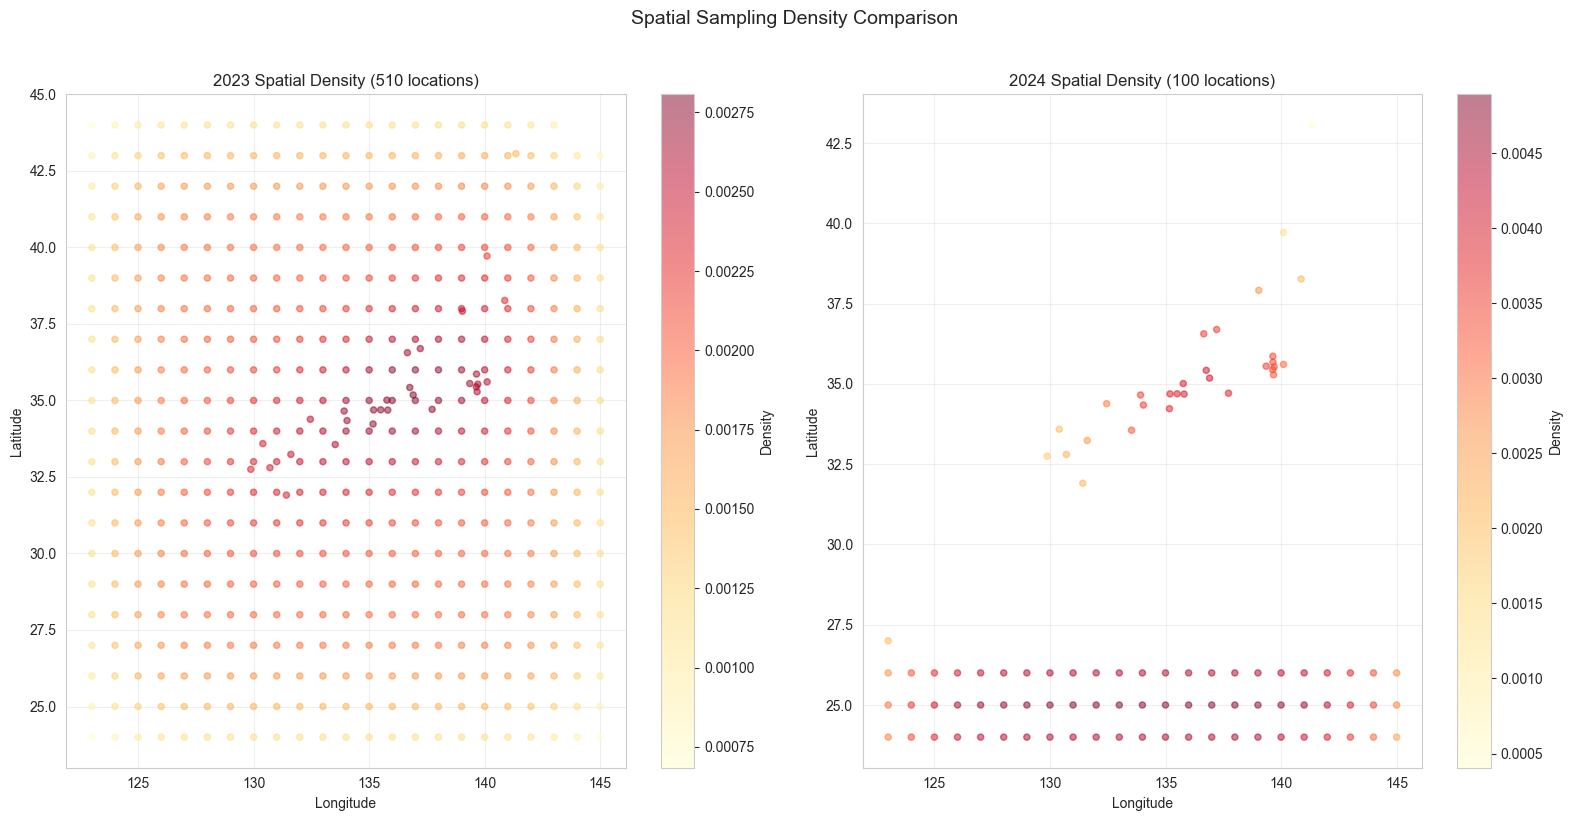

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

from scipy.stats import gaussian_kde

if len(locs_2023) > 0:
    xy_2023 = np.vstack([locs_2023['longitude'], locs_2023['latitude']])
    if xy_2023.shape[1] > 10:
        z_2023 = gaussian_kde(xy_2023)(xy_2023)
        scatter1 = axes[0].scatter(locs_2023['longitude'], locs_2023['latitude'], 
                                   c=z_2023, s=20, alpha=0.5, cmap='YlOrRd')
        plt.colorbar(scatter1, ax=axes[0], label='Density')
    else:
        axes[0].scatter(locs_2023['longitude'], locs_2023['latitude'], 
                       s=20, alpha=0.5, c='blue')
    axes[0].set_title(f'2023 Spatial Density ({len(locs_2023)} locations)', fontsize=12)
    axes[0].set_xlabel('Longitude')
    axes[0].set_ylabel('Latitude')
    axes[0].grid(True, alpha=0.3)

if len(locs_2024) > 0:
    xy_2024 = np.vstack([locs_2024['longitude'], locs_2024['latitude']])
    if xy_2024.shape[1] > 10:
        z_2024 = gaussian_kde(xy_2024)(xy_2024)
        scatter2 = axes[1].scatter(locs_2024['longitude'], locs_2024['latitude'], 
                                   c=z_2024, s=20, alpha=0.5, cmap='YlOrRd')
        plt.colorbar(scatter2, ax=axes[1], label='Density')
    else:
        axes[1].scatter(locs_2024['longitude'], locs_2024['latitude'], 
                       s=20, alpha=0.5, c='red')
    axes[1].set_title(f'2024 Spatial Density ({len(locs_2024)} locations)', fontsize=12)
    axes[1].set_xlabel('Longitude')
    axes[1].set_ylabel('Latitude')
    axes[1].grid(True, alpha=0.3)

plt.suptitle('Spatial Sampling Density Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

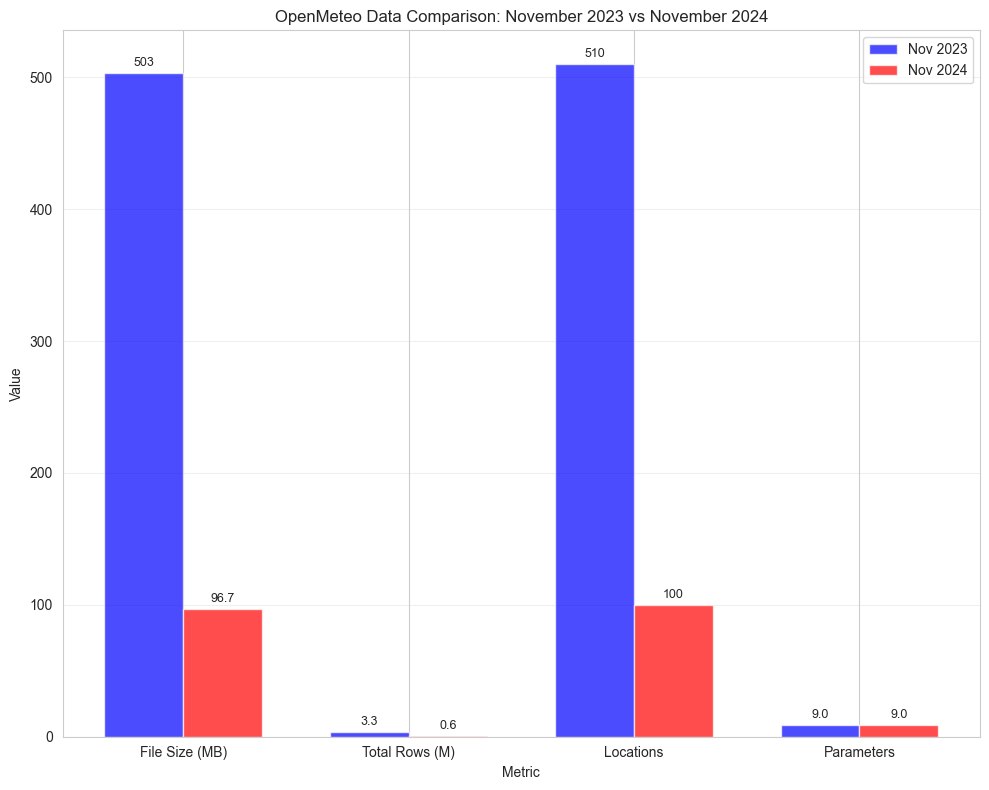

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

metrics = ['File Size (MB)', 'Total Rows (M)', 'Locations', 'Parameters']
values_2023 = [file_size_2023, df_2023.shape[0]/1e6, len(locations_2023), len(parameters_2023)]
values_2024 = [file_size_2024, df_2024.shape[0]/1e6, len(locations_2024), len(parameters_2024)]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, values_2023, width, label='Nov 2023', color='blue', alpha=0.7)
bars2 = ax.bar(x + width/2, values_2024, width, label='Nov 2024', color='red', alpha=0.7)

ax.set_xlabel('Metric')
ax.set_ylabel('Value')
ax.set_title('OpenMeteo Data Comparison: November 2023 vs November 2024')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}' if height < 100 else f'{int(height)}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()